# Laboratory 5 instruction part 2 - MLflow

In machine learning development, one of the most challenging aspects is maintaining reproducibility. This issue is particularly relevant to the experimental phase, when a lot of small, but influential code changes are constantly introduced.

After extensive experimentation with different model architectures, hyperparameters, and preprocessing techniques, researchers often find themselves unable to recreate their best-performing models because critical configuration details were not properly recorded.

## MLflow

[MLflow is an open-source platform](https://mlflow.org/) that addresses this challenge by providing systematic experiment tracking throughout the machine learning lifecycle. It automatically captures configurations, metrics, and artifacts from each model training run, transforming ad-hoc model development into a structured, reproducible process. In this notebook, we will learn how to use MLflow to properly track experiments for both traditional machine learning and deep learning workflows.


### Laboratory plan

1. **MLflow tracking server** configuration and deployment for experiment management
2. **Automatic logging mechanisms** for scikit-learn experiments
3. **Manual logging implementation** for PyTorch deep learning workflows
4. **Hyperparameter optimization exercise** - systematic hyperparameter exploration
5. **Best practices** for experiment organization, versioning, and cross-team reproducibility


## 1. MLflow Tracking server configuration

[MLflow Tracking](https://mlflow.org/docs/latest/tracking/) is the main component of MLflow, responsible for capturing, storing, and presenting metrics, logs, and other tracking data. MLflow is based on a client-server architecture, where the central MLflow server can serve potentially whole teams of data scientists. You can also simply run it as a local server from the commandline, as we will now.

You have two options for running MLflow:

#### Option 1: Local MLflow (Simple)
1. Open terminal - we recommend to split it into 2 shells or just open additional session.

1. Create a directory for MLflow artifacts storage:
```bash
mkdir mlflow-artifacts
```

2. Start the MLflow tracking server:
```bash
mlflow server \
  --backend-store-uri sqlite:///mlflow.db \
  --default-artifact-root ./mlflow-artifacts \
  --host 0.0.0.0 \
  --port 5001
```


**Important: Keep this terminal window open.** The MLflow server will continue running and be accessible at http://localhost:5001

#### Option 2: MLflow with Docker (Recommended for production-like setup)

1. Create a `docker-compose.yml` file:
```yaml
services:
  mlflow:
    image: ghcr.io/mlflow/mlflow:v2.9.2
    container_name: mlflow-server
    ports:
      - "5001:5000"
    volumes:
      - ./mlflow-data:/mlflow
    command:
      - mlflow
      - server
      - --backend-store-uri
      - sqlite:////mlflow/mlflow.db
      - --default-artifact-root
      - /mlflow/artifacts
      - --host
      - 0.0.0.0
      - --port
      - "5000"
    restart: unless-stopped
```

2. Start MLflow with Docker:
```bash
docker compose down -v
rm -rf mlflow-data
mkdir -p mlflow-data/artifacts
docker compose up -d
```

3. Check if it's running:
```bash
docker-compose ps
```

4. View logs (optional):
```bash
docker-compose logs -f mlflow
```

5. To stop the server later:
```bash
docker-compose down
```

**Important: Add MLflow files to .gitignore**

MLflow creates local files that should not be committed to Git. Add these lines to your `.gitignore`:

```
# MLflow
mlflow.db
mlflow-artifacts/
mlruns/
```

These files contain experiment data and artifacts that are specific to your local machine. In production, you would use a remote tracking server and artifact storage (like S3).

### Connecting to MLflow

To verify if the server runs properly, let's connect to it:

```python
import mlflow
import mlflow.sklearn

import warnings

warnings.filterwarnings("ignore")

mlflow.set_tracking_uri("http://localhost:5001")
print(f"Connected to MLflow at: {mlflow.get_tracking_uri()}")
```

**To stop the MLflow server later:**

- **Local setup**: Press `Ctrl+C` in the terminal where it's running
- **Docker setup**: Run `docker-compose down`

The server will shut down gracefully and save all your experiments.

**Note:** Keep the server running throughout this lab session. All your experiments will be logged to this server instance.


In [1]:
import mlflow
import mlflow.sklearn

import warnings

warnings.filterwarnings("ignore")

mlflow.set_tracking_uri("http://localhost:5001")
print(f"Connected to MLflow at: {mlflow.get_tracking_uri()}")

Connected to MLflow at: http://localhost:5001


## 2. Automatic logging with scikit-learn

### 2.1 Dataset preparation

In this section, we'll use the Ames Housing dataset to demonstrate MLflow's autologging capabilities with scikit-learn. Since we have already prepared the 2006-2008 data using DVC, we can use our preprocessed dataset here. 

In [2]:
import numpy as np
import pandas as pd

from feature_engine.encoding import RareLabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder

In [5]:
df = pd.read_parquet("data/ames_data_2006_2008.parquet")

df = df.sort_values(by=["YrSold"])

# As we have temporal data, the best way to evaluate our model is time (chronological) 
# split, where the newest data is used for testing. We will assume that we have the 
# data #for years 2006 and 2007, and evaluate using data from 2008.

df_train = df[df["YrSold"] < 2008]
df_test = df[df["YrSold"] == 2008]

y_train = df_train.pop("SalePrice")
y_test = df_test.pop("SalePrice")

categorical_features = df_train.select_dtypes(include="object").columns
numerical_features = df_train.select_dtypes(exclude="object").columns

In [6]:
median_imputer = SimpleImputer(strategy="median")
min_max_scaler = MinMaxScaler()
rare_encoder = RareLabelEncoder(tol=0.01, n_categories=0)
one_hot_encoder = OneHotEncoder(
    drop="first", sparse_output=False, handle_unknown="ignore"
)

num_pipeline = Pipeline(
    [("median_imputer", median_imputer), ("min_max_scaler", min_max_scaler)]
)

cat_pipeline = Pipeline(
    [("rare_encoder", rare_encoder), ("one_hot_encoder", one_hot_encoder)]
)

column_transformer = ColumnTransformer(
    [
        ("num_pipeline", num_pipeline, numerical_features),
        ("cat_pipeline", cat_pipeline, categorical_features),
    ],
    verbose_feature_names_out=False,
)
column_transformer.fit(df_train)

X_train = column_transformer.transform(df_train)
X_test = column_transformer.transform(df_test)

In [7]:
print(f"Training samples: {X_train.shape[0]}")
print(f"Test samples: {X_test.shape[0]}")
print(f"Number of features: {X_train.shape[1]}")

Training samples: 1312
Test samples: 621
Number of features: 181


### 2.2 Training with MLflow autologging

Autologging is a powerful built-in capability of MLflow, enabling fully automated and near-zero code integration of MLflow with many popular frameworks. In particular, it works really well with scikit-learn, thanks to its highly unified API. Let's try this out - we will enable autologging, and then train a bunch of different models.

In [8]:
mlflow.sklearn.autolog(
    log_input_examples=True, log_model_signatures=True, log_models=False, silent=False
)

mlflow.set_experiment("ames-housing-autolog")

2026/03/22 19:00:17 WARNING mlflow.utils.autologging_utils: MLflow sklearn autologging is known to be compatible with 0.24.1 <= scikit-learn <= 1.6.1, but the installed version is 1.7.0. If you encounter errors during autologging, try upgrading / downgrading scikit-learn to a compatible version, or try upgrading MLflow.
2026/03/22 19:00:27 INFO mlflow.tracking.fluent: Experiment with name 'ames-housing-autolog' does not exist. Creating a new experiment.


<Experiment: artifact_location='/home/adrian/Projekty/Task/MLOps_course_AGH/lab05/mlflow-artifacts/1', creation_time=1774202427087, experiment_id='1', last_update_time=1774202427087, lifecycle_stage='active', name='ames-housing-autolog', tags={}>

In [9]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor

models = [
    ("Ridge Regression", Ridge()),
    ("Decision Tree", DecisionTreeRegressor(max_depth=10, random_state=42)),
    ("K-Nearest Neighbors", KNeighborsRegressor(n_neighbors=10)),
    ("Random Forest", RandomForestRegressor(n_estimators=100, random_state=42)),
    ("Gradient Boosting", GradientBoostingRegressor(n_estimators=100, random_state=42)),
]

In [10]:
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score

def fit_sklearn_models_with_cv(models, X_train, X_test, y_train, y_test):
    results = {}

    for model_name, model in models:
        # start MLflow run - a unit grouping logs from different model runs
        # everything within this context manager will get logged as a run
        with mlflow.start_run(run_name=model_name):
            model.fit(X_train, y_train)

            y_pred = model.predict(X_test)

            rmse = root_mean_squared_error(y_test, y_pred)
            mae = mean_absolute_error(y_test, y_pred)
            r2 = r2_score(y_test, y_pred)

            cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring="r2")
            cv_mean = cv_scores.mean()
            cv_std = cv_scores.std()
            
            # log additional custom metrics, in addition to autologging
            mlflow.log_metric("cv_r2_mean", cv_mean)
            mlflow.log_metric("cv_r2_std", cv_std)

            results[model_name] = {
                "rmse": rmse,
                "mae": mae,
                "r2": r2,
                "cv_r2_mean": cv_mean,
            }

            print(f"\n{model_name}:")
            print(f"  RMSE: {rmse:.2f}")
            print(f"  MAE: {mae:.2f}")
            print(f"  R^2: {r2:.3f}")
            print(f"  CV R^2 (mean ± std): {cv_mean:.3f} ± {cv_std:.3f}")

In [11]:
fit_sklearn_models_with_cv(models, X_train, X_test, y_train, y_test)

2026/03/22 19:07:09 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/03/22 19:07:10 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/03/22 19:07:11 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/03/22 19:07:11 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/03/22 19:07:11 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/03/22 19:07:12 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'



Ridge Regression:
  RMSE: 23450.39
  MAE: 16430.79
  R^2: 0.904
  CV R^2 (mean ± std): 0.880 ± 0.037
🏃 View run Ridge Regression at: http://localhost:5001/#/experiments/1/runs/7467a4dde4c846e386cd30ea809e3dc8
🧪 View experiment at: http://localhost:5001/#/experiments/1


2026/03/22 19:07:12 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/03/22 19:07:13 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/03/22 19:07:13 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/03/22 19:07:14 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/03/22 19:07:14 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/03/22 19:07:14 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'



Decision Tree:
  RMSE: 36860.51
  MAE: 23270.66
  R^2: 0.762
  CV R^2 (mean ± std): 0.726 ± 0.080
🏃 View run Decision Tree at: http://localhost:5001/#/experiments/1/runs/287ad12320814647b5ec0742d0f10b26
🧪 View experiment at: http://localhost:5001/#/experiments/1


2026/03/22 19:07:15 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/03/22 19:07:15 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/03/22 19:07:16 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/03/22 19:07:17 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/03/22 19:07:17 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/03/22 19:07:17 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'


...

🏃 View run K-Nearest Neighbors at: http://localhost:5001/#/experiments/1/runs/ab14b7335c2b47c79219471212ba09c6
🧪 View experiment at: http://localhost:5001/#/experiments/1


2026/03/22 19:07:24 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/03/22 19:07:29 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/03/22 19:07:33 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/03/22 19:07:39 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/03/22 19:07:45 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'



Random Forest:
  RMSE: 25896.23
  MAE: 15509.71
  R^2: 0.883
  CV R^2 (mean ± std): 0.870 ± 0.043
🏃 View run Random Forest at: http://localhost:5001/#/experiments/1/runs/16d06e01f1164795ba41ca078bf3d92c
🧪 View experiment at: http://localhost:5001/#/experiments/1


2026/03/22 19:07:54 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/03/22 19:07:57 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/03/22 19:08:00 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/03/22 19:08:02 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/03/22 19:08:05 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/03/22 19:08:07 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'



Gradient Boosting:
  RMSE: 21572.13
  MAE: 13809.38
  R^2: 0.919
  CV R^2 (mean ± std): 0.898 ± 0.031
🏃 View run Gradient Boosting at: http://localhost:5001/#/experiments/1/runs/f56937059205475e9cdc84e5b027eeba
🧪 View experiment at: http://localhost:5001/#/experiments/1


Open the MLflow dashboard at http://localhost:5000/ and go to the Experiments tab. On the left, you have the experiment name, and when you select it, the list of all experiments will show up. Click through the interface and familiarize yourself with the most important elements:

1. What columns can be selected
2. Pick a particular run and check what values are logged automatically
3. Select columns to compare a given metric between runs, e.g. MAE
4. Sort algorithms by the selected metric to pick the best one

1. What columns can be selected
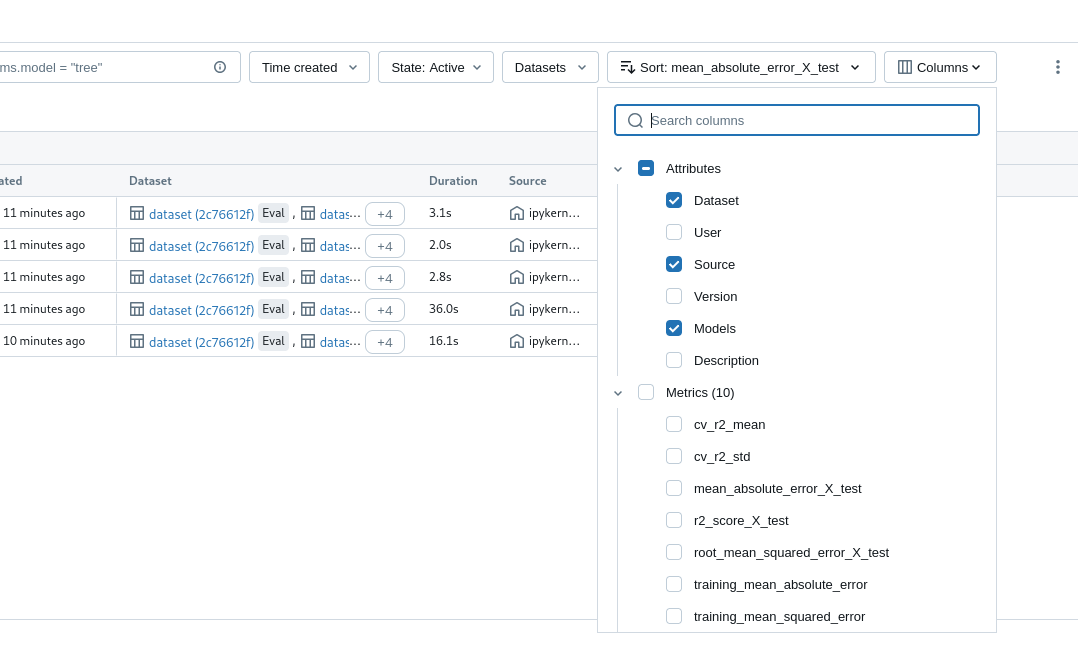

2. Pick a particular run and check what values are logged automatically
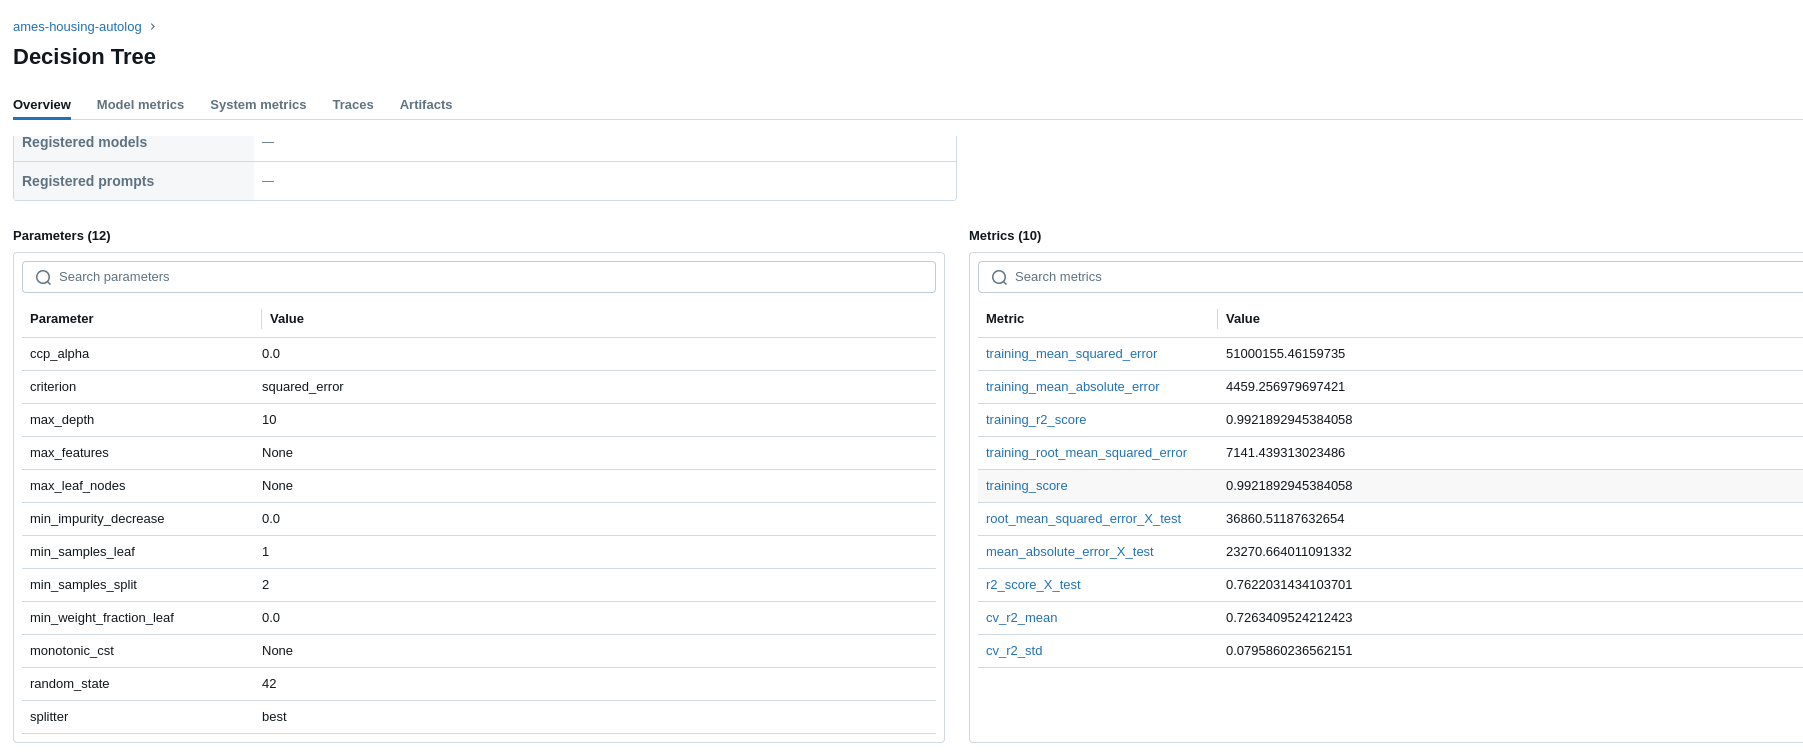


3. Select columns to compare a given metric between runs, e.g. MAE
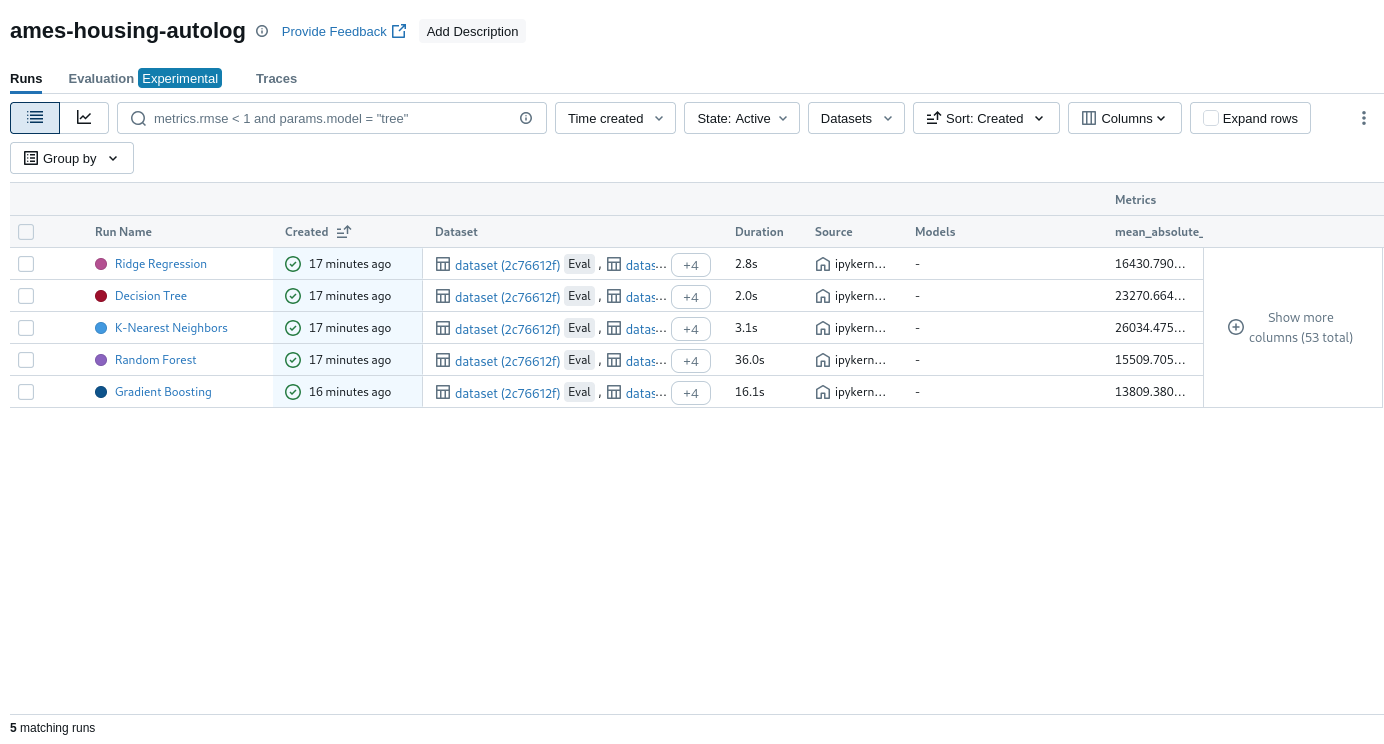

4. Sort algorithms by the selected metric to pick the best one
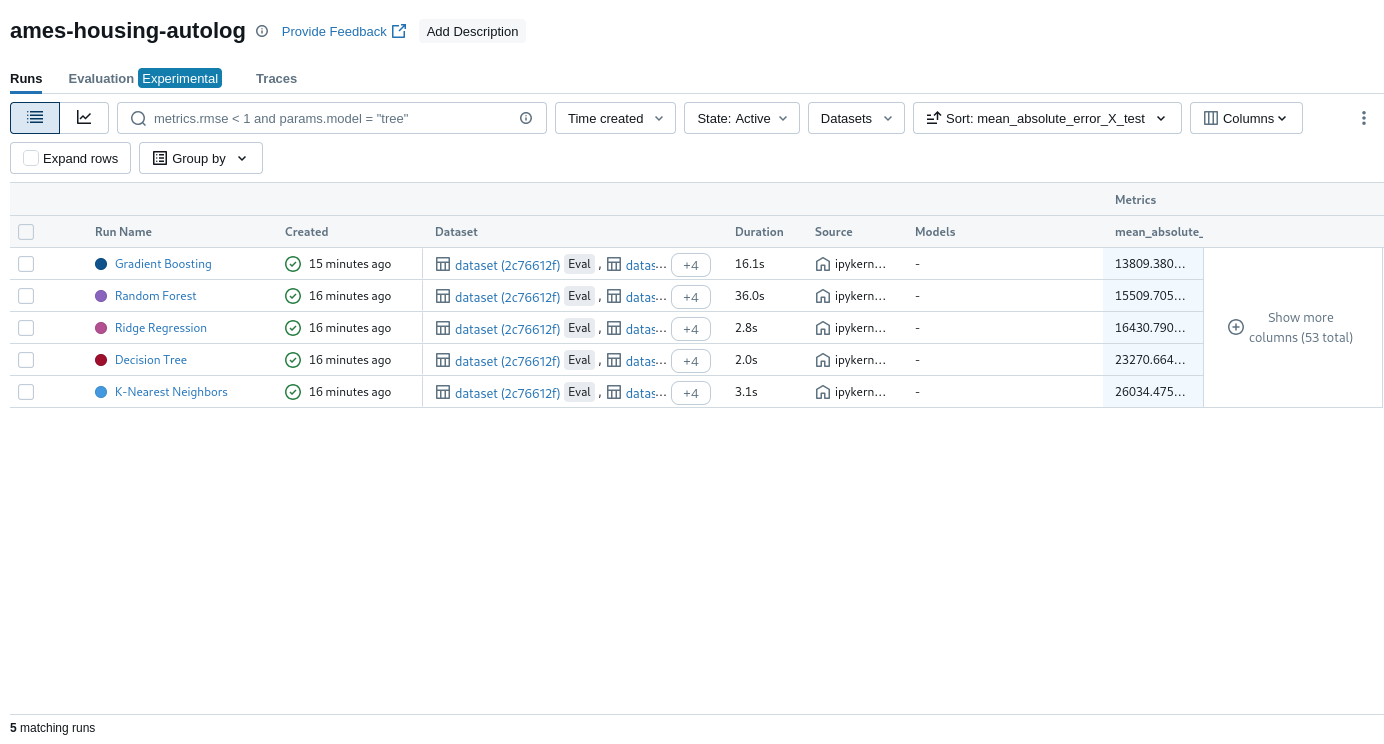

## 2.3 Connecting DVC and MLflow

You've already used DVC to version your dataset in the first part of this lab. Now let's connect DVC metadata with MLflow experiments to create a complete audit trail. When you run experiments, you want to know:
- Which version of the data was used?
- Can I reproduce these exact results?
- What changed between experiments?

By logging DVC metadata in MLflow, you create a link between your data versions and experiment results.

### Reading DVC metadata

DVC stores metadata in `.dvc` files. Let's read it:

In [12]:
import yaml

def get_dvc_metadata(dvc_file_path):
    with open(dvc_file_path, 'r') as f:
        dvc_data = yaml.safe_load(f)
    
    metadata = {
        'md5': dvc_data['outs'][0]['md5'],
        'size': dvc_data['outs'][0]['size'],
        'path': dvc_data['outs'][0]['path']
    }
    return metadata

dvc_metadata = get_dvc_metadata('data/ames_data_2006_2008.parquet.dvc')
print("DVC Metadata:")
print(f"MD5 hash: {dvc_metadata['md5']}")
print(f"File size: {dvc_metadata['size']} bytes")
print(f"Data path: {dvc_metadata['path']}")

DVC Metadata:
MD5 hash: f44053333f88a0646819936b37f000ee
File size: 162560 bytes
Data path: ames_data_2006_2008.parquet


### Exercise 1 - Logging DVC metadata in MLflow

We have trained 5 different models. The results of all of them can now be compared in MLflow. Now let's modify our training to include DVC metadata. This creates a complete audit trail:
- **Git commit** → tracks code version
- **DVC hash** → tracks data version
- **MLflow run** → tracks experiment results

Your task is to:
1. Run 5 more experiments with different parameters and models from scikit-learn. You can use any [supervised learning methods from scikit-learn](https://scikit-learn.org/stable/supervised_learning.html). Find some other models or parameters to tune our current models with and run the experiments again. 
2. Use the function `fit_sklearn_models_with_cv()` created above, or you can write your own if you want.
3. Make sure you have included DVC metadata logging. You can initialize dvc_metadata by calling above defined `get_dvc_metadata` function with the .dvc metadata file. Then you can just for each experiment add param logging like:

```python
mlflow.log_param("param_name", "value you want to log") # e.g md5
```

In [56]:
mlflow.sklearn.autolog(
    log_input_examples=True, log_model_signatures=True, log_models=False, silent=False
)

mlflow.set_experiment("ames-housing-autolog-baseline")

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score

models = [
    ("Ridge Regression", Ridge()),
    ("Decision Tree", DecisionTreeRegressor(max_depth=10, random_state=42)),
    ("K-Nearest Neighbors", KNeighborsRegressor(n_neighbors=10)),
    ("Random Forest", RandomForestRegressor(n_estimators=100, random_state=42)),
    ("Gradient Boosting", GradientBoostingRegressor(n_estimators=100, random_state=42)),
]


def fit_sklearn_models_with_cv(models, X_train, X_test, y_train, y_test):
    results = {}

    for model_name, model in models:
        # start MLflow run - a unit grouping logs from different model runs
        # everything within this context manager will get logged as a run
        with mlflow.start_run(run_name=model_name):
            model.fit(X_train, y_train)

            y_pred = model.predict(X_test)

            rmse = root_mean_squared_error(y_test, y_pred)
            mae = mean_absolute_error(y_test, y_pred)
            r2 = r2_score(y_test, y_pred)

            cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring="r2")
            cv_mean = cv_scores.mean()
            cv_std = cv_scores.std()

            # log additional custom metrics, in addition to autologging
            mlflow.log_metric("cv_r2_mean", cv_mean)
            mlflow.log_metric("cv_r2_std", cv_std)

            results[model_name] = {
                "rmse": rmse,
                "mae": mae,
                "r2": r2,
                "cv_r2_mean": cv_mean,
            }

            print(f"\n{model_name}:")
            print(f"  RMSE: {rmse:.2f}")
            print(f"  MAE: {mae:.2f}")
            print(f"  R^2: {r2:.3f}")
            print(f"  CV R^2 (mean ± std): {cv_mean:.3f} ± {cv_std:.3f}")

fit_sklearn_models_with_cv(models, X_train, X_test, y_train, y_test)

2026/03/24 19:25:00 WARNING mlflow.utils.autologging_utils: MLflow sklearn autologging is known to be compatible with 0.24.1 <= scikit-learn <= 1.6.1, but the installed version is 1.7.0. If you encounter errors during autologging, try upgrading / downgrading scikit-learn to a compatible version, or try upgrading MLflow.
2026/03/24 19:25:01 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/03/24 19:25:02 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/03/24 19:25:02 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/03/24 19:25:02 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/03/24 19:25:03 WARNING mlflow.sklearn: Fa


Ridge Regression:
  RMSE: 23450.39
  MAE: 16430.79
  R^2: 0.904
  CV R^2 (mean ± std): 0.880 ± 0.037
🏃 View run Ridge Regression at: http://localhost:5001/#/experiments/3/runs/8e2edc4a528e4fe5bcdac66b5d647cd8
🧪 View experiment at: http://localhost:5001/#/experiments/3


2026/03/24 19:25:04 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/03/24 19:25:05 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/03/24 19:25:05 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/03/24 19:25:05 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/03/24 19:25:05 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'



Decision Tree:
  RMSE: 36860.51
  MAE: 23270.66
  R^2: 0.762
  CV R^2 (mean ± std): 0.726 ± 0.080
🏃 View run Decision Tree at: http://localhost:5001/#/experiments/3/runs/b52228b557d5490f973a97655c16bb8a
🧪 View experiment at: http://localhost:5001/#/experiments/3


2026/03/24 19:25:06 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/03/24 19:25:07 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/03/24 19:25:08 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/03/24 19:25:08 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/03/24 19:25:09 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/03/24 19:25:09 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/03/24 19:25:11 WARNING mlflow.sklearn: Failed t


K-Nearest Neighbors:
  RMSE: 38325.08
  MAE: 26034.48
  R^2: 0.743
  CV R^2 (mean ± std): 0.656 ± 0.050
🏃 View run K-Nearest Neighbors at: http://localhost:5001/#/experiments/3/runs/f4625bb3142e48fea8bc3b5835922814
🧪 View experiment at: http://localhost:5001/#/experiments/3


2026/03/24 19:25:21 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/03/24 19:25:36 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/03/24 19:25:44 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/03/24 19:25:54 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/03/24 19:26:00 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/03/24 19:26:04 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'



Random Forest:
  RMSE: 25896.23
  MAE: 15509.71
  R^2: 0.883
  CV R^2 (mean ± std): 0.870 ± 0.043
🏃 View run Random Forest at: http://localhost:5001/#/experiments/3/runs/f1358fa5c633483bafd6d4b190b78fa3
🧪 View experiment at: http://localhost:5001/#/experiments/3


2026/03/24 19:26:06 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/03/24 19:26:08 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/03/24 19:26:09 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/03/24 19:26:10 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/03/24 19:26:12 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'



Gradient Boosting:
  RMSE: 21572.13
  MAE: 13809.38
  R^2: 0.919
  CV R^2 (mean ± std): 0.898 ± 0.031
🏃 View run Gradient Boosting at: http://localhost:5001/#/experiments/3/runs/539d7c020be04de2bd7248e762f45e91
🧪 View experiment at: http://localhost:5001/#/experiments/3


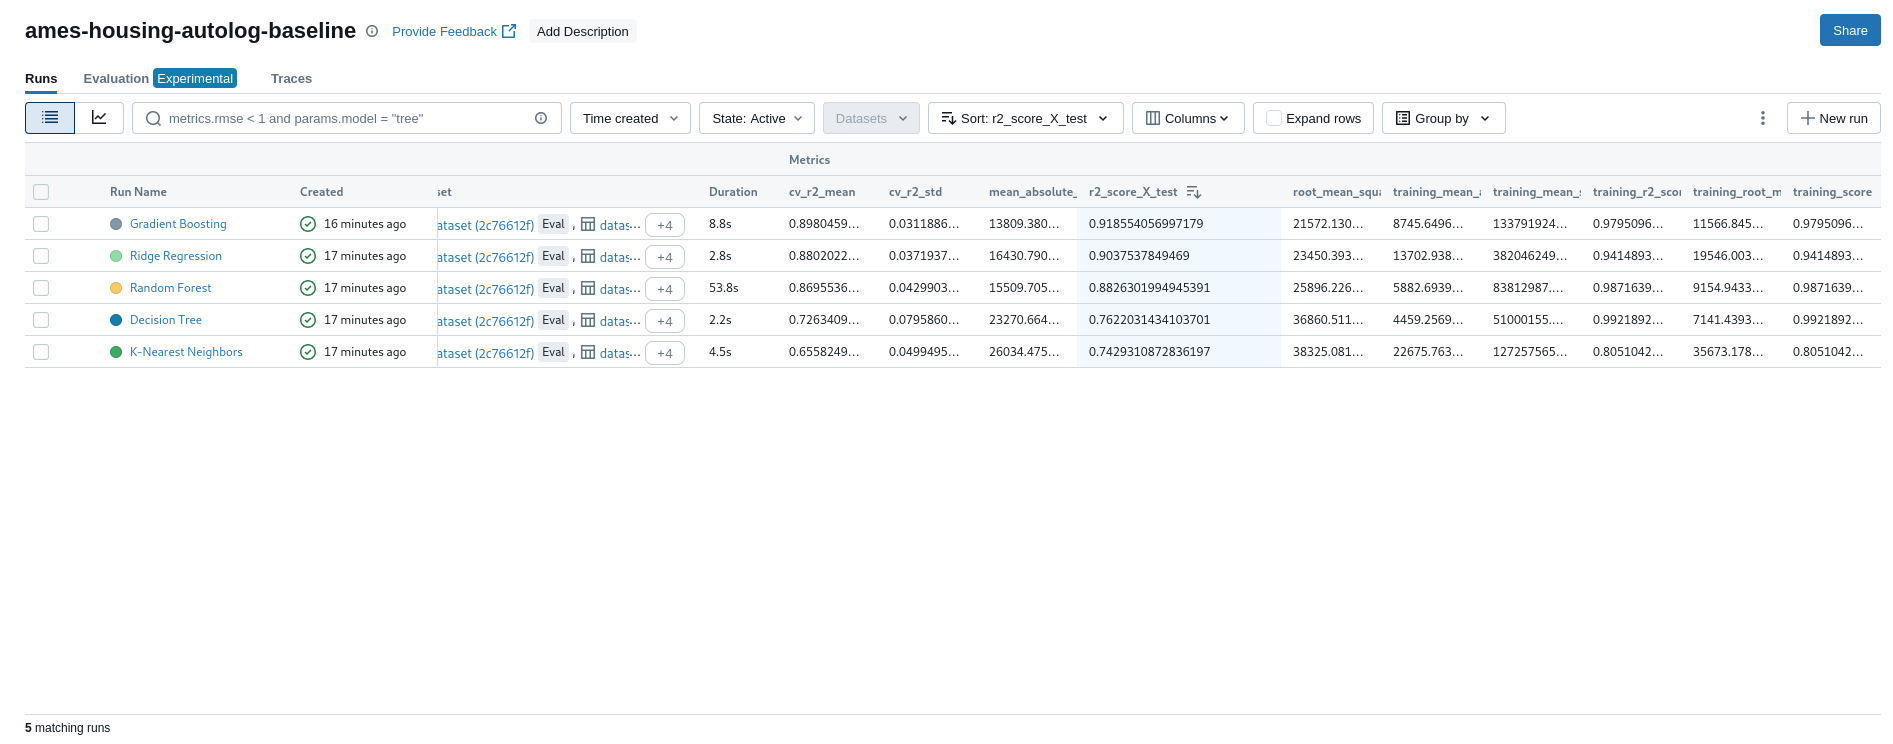

In [28]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet
from sklearn.svm import SVR
from sklearn.ensemble import AdaBoostRegressor

from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score

models = [
    ("Ridge Regression", Ridge()),
    ("Decision Tree", DecisionTreeRegressor(max_depth=10, random_state=42)),
    ("K-Nearest Neighbors", KNeighborsRegressor(n_neighbors=10)),
    ("Random Forest", RandomForestRegressor(n_estimators=100, random_state=42)),
    ("Gradient Boosting", GradientBoostingRegressor(n_estimators=100, random_state=42)),
    ("Extra Trees", ExtraTreesRegressor(n_estimators=200, random_state=42)),
    ("Lasso Regression", Lasso(alpha=1)),
    ("ElasticNet", ElasticNet(alpha=0.1, l1_ratio=0.5)),
    ("SVR", SVR(kernel="rbf", C=10, epsilon=0.1)),
    ("AdaBoost", AdaBoostRegressor(n_estimators=50, learning_rate=0.1, random_state=42)),


]

def fit_sklearn_models_with_cv(models, X_train, X_test, y_train, y_test):
    results = {}

    for model_name, model in models:
        # start MLflow run - a unit grouping logs from different model runs
        # everything within this context manager will get logged as a run
        with mlflow.start_run(run_name=model_name):
            model.fit(X_train, y_train)

            y_pred = model.predict(X_test)

            rmse = root_mean_squared_error(y_test, y_pred)
            mae = mean_absolute_error(y_test, y_pred)
            r2 = r2_score(y_test, y_pred)

            cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring="r2")
            cv_mean = cv_scores.mean()
            cv_std = cv_scores.std()

            # log additional custom metrics, in addition to autologging
            mlflow.log_metric("cv_r2_mean", cv_mean)
            mlflow.log_metric("cv_r2_std", cv_std)
            mlflow.log_metric("rmse", rmse)
            mlflow.log_metric("mae", mae)
            mlflow.log_metric("r2", r2)

            # logging parameters from DVC
            dvc_metadata = get_dvc_metadata('data/ames_data_2006_2008.parquet.dvc')

            mlflow.log_param("data_md5", dvc_metadata['md5'])
            mlflow.log_param("data_size", dvc_metadata['size'])
            mlflow.log_param("data_path", dvc_metadata['path'])
            #

            results[model_name] = {
                "rmse": rmse,
                "mae": mae,
                "r2": r2,
                "cv_r2_mean": cv_mean,
            }

            print(f"\n{model_name}:")
            print(f"  RMSE: {rmse:.2f}")
            print(f"  MAE: {mae:.2f}")
            print(f"  R^2: {r2:.3f}")
            print(f"  CV R^2 (mean ± std): {cv_mean:.3f} ± {cv_std:.3f}")

fit_sklearn_models_with_cv(models, X_train, X_test, y_train, y_test)

2026/03/22 22:41:55 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/03/22 22:41:56 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/03/22 22:41:56 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/03/22 22:41:56 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/03/22 22:41:57 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/03/22 22:41:57 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'



Ridge Regression:
  RMSE: 23450.39
  MAE: 16430.79
  R^2: 0.904
  CV R^2 (mean ± std): 0.880 ± 0.037
🏃 View run Ridge Regression at: http://localhost:5001/#/experiments/1/runs/6ad82396ecf34ece9dcc9fe1c07caf61
🧪 View experiment at: http://localhost:5001/#/experiments/1


2026/03/22 22:41:58 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/03/22 22:41:58 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/03/22 22:41:59 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/03/22 22:41:59 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/03/22 22:41:59 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/03/22 22:41:59 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/03/22 22:42:00 WARNING mlflow.sklearn: Failed t


Decision Tree:
  RMSE: 36860.51
  MAE: 23270.66
  R^2: 0.762
  CV R^2 (mean ± std): 0.726 ± 0.080
🏃 View run Decision Tree at: http://localhost:5001/#/experiments/1/runs/6723fc9a73a24a20b7ec6015f7f6d2c7
🧪 View experiment at: http://localhost:5001/#/experiments/1


2026/03/22 22:42:01 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/03/22 22:42:01 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/03/22 22:42:01 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/03/22 22:42:02 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/03/22 22:42:02 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/03/22 22:42:03 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'


...


ElasticNet:
  RMSE: 27319.47
  MAE: 18594.52
  R^2: 0.869
  CV R^2 (mean ± std): 0.826 ± 0.031
🏃 View run ElasticNet at: http://localhost:5001/#/experiments/1/runs/6036b55d62bd4145a840b2a5b3237b39
🧪 View experiment at: http://localhost:5001/#/experiments/1


2026/03/22 22:43:51 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/03/22 22:43:56 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/03/22 22:43:58 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/03/22 22:43:59 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/03/22 22:44:00 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/03/22 22:44:01 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/03/22 22:44:03 WARNING mlflow.sklearn: Failed t


SVR:
  RMSE: 77238.99
  MAE: 54616.24
  R^2: -0.044
  CV R^2 (mean ± std): -0.120 ± 0.135
🏃 View run SVR at: http://localhost:5001/#/experiments/1/runs/a74b7d5306cd4d0a9f1f0238197668cd
🧪 View experiment at: http://localhost:5001/#/experiments/1


2026/03/22 22:44:04 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/03/22 22:44:05 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/03/22 22:44:06 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/03/22 22:44:07 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/03/22 22:44:08 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'



AdaBoost:
  RMSE: 34437.28
  MAE: 23819.71
  R^2: 0.792
  CV R^2 (mean ± std): 0.766 ± 0.081
🏃 View run AdaBoost at: http://localhost:5001/#/experiments/1/runs/393416cf61c744ada445ef7f0dac0aea
🧪 View experiment at: http://localhost:5001/#/experiments/1


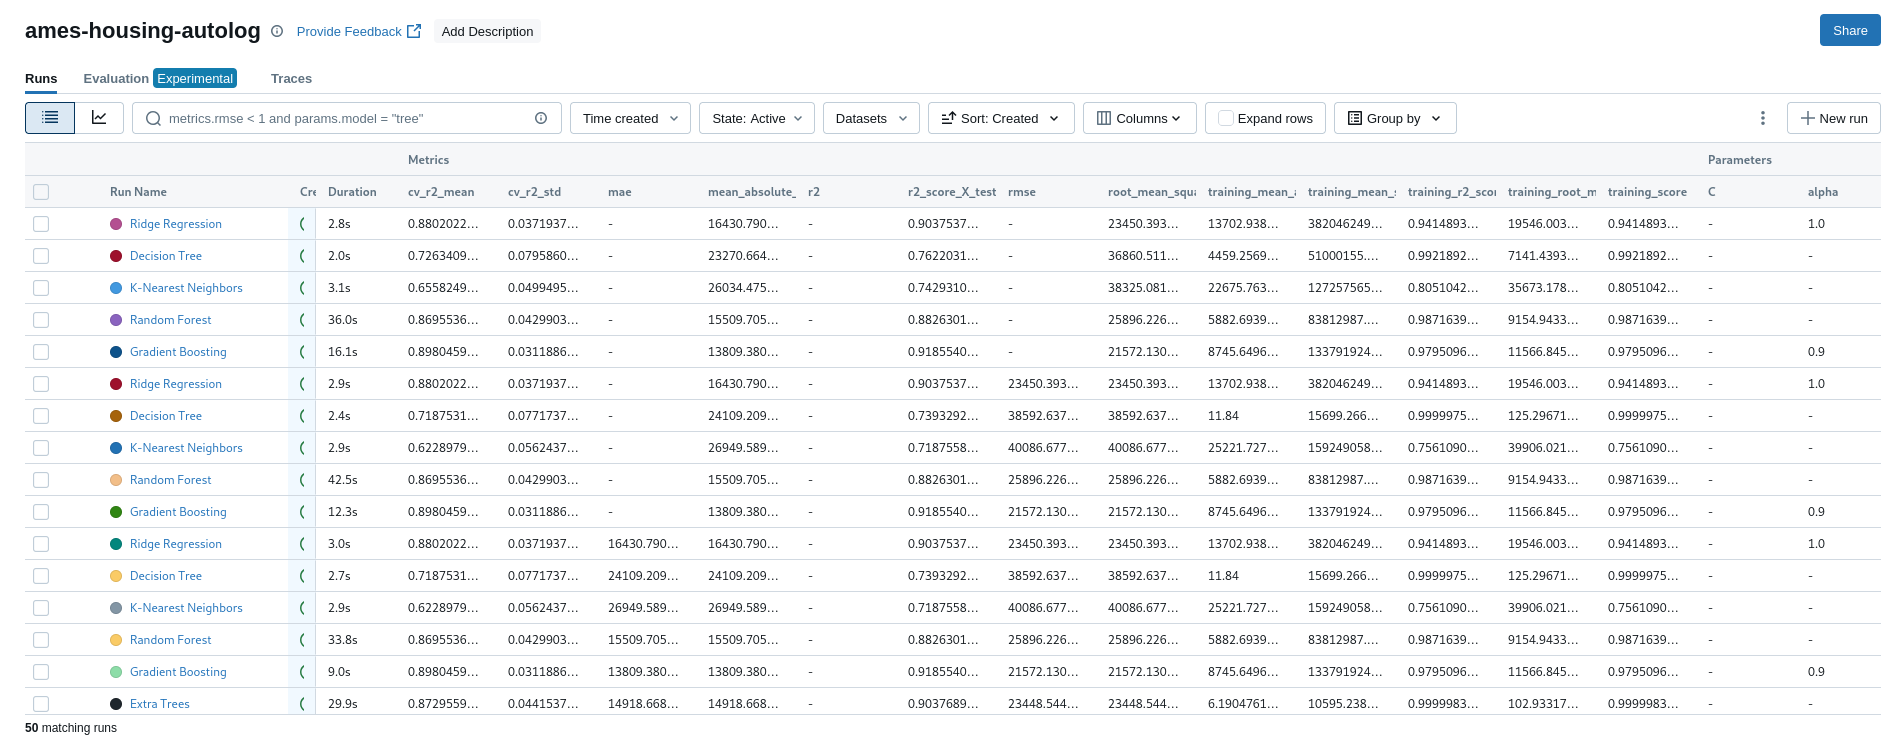

## 3. Manual logging with PyTorch

In this section, we'll implement manual logging for PyTorch models. While scikit-learn has autologging, PyTorch requires manual tracking - giving us full control over what and when to log. MLflow supports autologging for [PyTorch Lightning](https://lightning.ai/docs/pytorch/stable/), but we often need low-level control of pure PyTorch.

Note that we need to turn off scikit-learn autologging! Since we are using a Jupyter Notebook, MLflow uses the previously configured autologging unless explicitly turned off.

In [29]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import KFold

# disable sklearn autologging!
mlflow.sklearn.autolog(disable=True)

mlflow.set_experiment("pytorch-housing-manual")

2026/03/22 22:54:27 INFO mlflow.tracking.fluent: Experiment with name 'pytorch-housing-manual' does not exist. Creating a new experiment.


<Experiment: artifact_location='/home/adrian/Projekty/Task/MLOps_course_AGH/lab05/mlflow-artifacts/2', creation_time=1774216467050, experiment_id='2', last_update_time=1774216467050, lifecycle_stage='active', name='pytorch-housing-manual', tags={}>

### 3.1 Targets transformation

Before training the neural network, we will transform the training target, in order to stabilize the training. To see why, let's plot the house prices:

<Axes: ylabel='Frequency'>

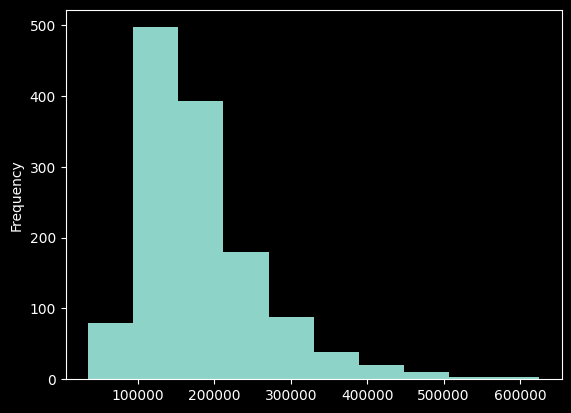

In [30]:
y_train.plot.hist()

Training on such targets is possible, but very large target values easily risk overflow, particularly when a loss function like mean squared error is used. We will use the log-transform to transform this distribution, as it's near-exponential, so it should bring it closer to normal, and also greatly reduce the values range.

Of course, we will need to transform the network predictions back again to evaluate them.

<Axes: ylabel='Frequency'>

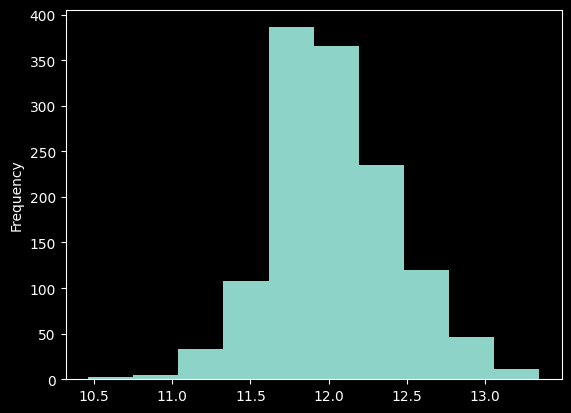

In [31]:
y_train_log = np.log1p(y_train)

pd.Series(y_train_log).plot.hist()

### 3.2 Define and train the model

Since we have tabular data, we will use a simple 2-layer multilayer perceptron (MLP).

In [32]:
class HousePriceNet(nn.Module):
    def __init__(self, input_dim, hidden_dim=128, dropout_rate=0.2):
        super(HousePriceNet, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout_rate)
        self.fc2 = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)
        return x

For training, we will check both the 5-fold CV performance, and the traditional train-test split. Cross-validation will give us an additional, robust performance estimation, as well as standard deviation, which is useful for comparing performances of different models. After all, if the difference between models would be within one standard deviation, it wouldn't really be meaningful.


In [33]:
import torch.nn as nn


class PyTorchTrainer:
    def __init__(
        self, model_class: type[nn.Module], config: dict
    ):
        required_keys = ['hidden_units', 'dropout', 'batch_size', 'learning_rate', 
                         'log_interval', 'epochs', 'name']
        missing = [key for key in required_keys if key not in config]
        if missing:
            raise ValueError(f"Missing required config keys: {missing}")
        
        self.model_class = model_class
        self.config = config

    def create_model(self, input_dim: int) -> nn.Module:
        return self.model_class(
            input_dim=input_dim,
            hidden_dim=self.config["hidden_units"],
            dropout_rate=self.config["dropout"],
        )

    def create_data_loader(
        self, X: torch.Tensor, y: torch.Tensor, shuffle: bool = True
    ) -> DataLoader:
        dataset = TensorDataset(X, y)
        return DataLoader(
            dataset, batch_size=self.config["batch_size"], shuffle=shuffle
        )

    def train_epoch(
        self,
        model: nn.Module,
        train_loader: DataLoader,
        criterion: nn.Module,
        optimizer: optim.Optimizer,
    ) -> float:
        model.train()
        epoch_loss = 0.0
        batch_count = 0

        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
            batch_count += 1

        return epoch_loss / batch_count

    def train_model(
        self,
        model: nn.Module,
        train_loader: DataLoader,
        epochs: int,
        metric_prefix: str = "",
    ) -> None:
        criterion = nn.MSELoss()
        optimizer = optim.Adam(model.parameters(), lr=self.config["learning_rate"])

        for epoch in range(epochs):
            avg_mse = self.train_epoch(model, train_loader, criterion, optimizer)

            if epoch % self.config["log_interval"] == 0:
                metric_name = (
                    f"{metric_prefix}train_mse" if metric_prefix else "train_mse"
                )
                # manually log metric value, with a given name and step value
                mlflow.log_metric(metric_name, avg_mse, step=epoch)

    @torch.no_grad()
    def evaluate_model(
        self,
        model: nn.Module,
        X: torch.Tensor,
        y_test: torch.Tensor,
        log_prefix: str = "",
    ) -> dict[str, float]:
        model.eval()
        
        y_pred_norm = model(X)

        # revert the logarithm with exponent
        y_pred = np.expm1(y_pred_norm.numpy())
        y_test = y_test.numpy()

        rmse = root_mean_squared_error(y_test.ravel(), y_pred.ravel())
        mae = mean_absolute_error(y_test.ravel(), y_pred.ravel())
        r2 = r2_score(y_test.ravel(), y_pred.ravel())

        if log_prefix:
            # manually log metrics that we want
            mlflow.log_metric(f"{log_prefix}_rmse", rmse)
            mlflow.log_metric(f"{log_prefix}_mae", mae)
            mlflow.log_metric(f"{log_prefix}_r2", r2)

        return {"rmse": rmse, "mae": mae, "r2": r2}

    def run_cross_validation(
        self, X_train: torch.Tensor, y_train: torch.Tensor, n_splits: int = 5
    ) -> tuple[float, float, list[float]]:
        kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
        cv_scores = []

        for fold, (train_idx, val_idx) in enumerate(kf.split(X_train)):
            print(f"\nTraining Fold {fold + 1}/{n_splits}...")

            X_fold_train = X_train[train_idx]
            y_fold_train = y_train[train_idx]
            X_fold_val = X_train[val_idx]
            y_fold_val = y_train[val_idx]

            fold_model = self.create_model(X_train.shape[1])
            fold_loader = self.create_data_loader(X_fold_train, y_fold_train)

            self.train_model(
                fold_model,
                fold_loader,
                self.config["epochs"],
                metric_prefix=f"fold_{fold + 1}_",
            )

            # transform validation data with exponent back to original unit
            y_fold_val = np.expm1(y_fold_val)
            
            val_metrics = self.evaluate_model(
                fold_model, X_fold_val, y_fold_val, log_prefix=f"fold_{fold + 1}_val"
            )

            cv_scores.append(val_metrics["r2"])
            print(
                f"  Fold {fold + 1} "
                f"Validation - RMSE: {val_metrics['rmse']:.2f}, "
                f"MAE: {val_metrics['mae']:.2f} "
                f"R^2: {val_metrics['r2']:.3f}"
            )

        return np.mean(cv_scores), np.std(cv_scores), cv_scores

    def _log_dvc_metadata(self, dvc_file_path: str = 'data/ames_data_2006_2008.parquet.dvc'):
        try:
            dvc_metadata = get_dvc_metadata(dvc_file_path)
            
            mlflow.log_param("data_dvc_md5", dvc_metadata['md5'])
            mlflow.log_param("data_dvc_size", dvc_metadata['size'])
            mlflow.log_param("data_path", dvc_metadata['path'])
            print(f"Logged DVC metadata: {dvc_metadata['md5'][:8]}...")
        except FileNotFoundError:
            print("DVC file not found - skipping metadata logging")
        except Exception as e:
            print(f"Could not log DVC metadata: {e}")

    def fit(
        self,
        X_train: pd.DataFrame | np.ndarray,
        y_train: pd.Series | np.ndarray,
        X_test: pd.DataFrame | np.ndarray,
        y_test: pd.Series | np.ndarray,
    ) -> dict:
        X_train, X_test, y_train, y_test = self._prepare_tensors(
            X_train, X_test, y_train, y_test
        )

        with mlflow.start_run(run_name=self.config["name"]):
            mlflow.log_params(self.config)
            
            # Log DVC metadata for data versioning
            self._log_dvc_metadata()

            print(f"Starting 5-fold cross-validation for {self.config['name']}...")
            cv_mean, cv_std, cv_scores = self.run_cross_validation(X_train, y_train)

            mlflow.log_metric("cv_r2_mean", cv_mean)
            mlflow.log_metric("cv_r2_std", cv_std)

            print(
                f"\nCross-validation complete. Mean R^2: {cv_mean:.3f} (+/- {cv_std:.3f})"
            )
            print("\nTraining final model on all training data...")

            final_model = self.create_model(X_train.shape[1])
            final_loader = self.create_data_loader(X_train, y_train)

            self.train_model(
                final_model,
                final_loader,
                self.config["epochs"],
                metric_prefix="final_model_",
            )

            print("\nEvaluating on test set...")
            test_metrics = self.evaluate_model(final_model, X_test, y_test)

            mlflow.log_metric("test_rmse", test_metrics["rmse"])
            mlflow.log_metric("test_mae", test_metrics["mae"])
            mlflow.log_metric("test_r2", test_metrics["r2"])

            self._print_results(test_metrics, cv_mean, cv_std)

            return {
                "rmse": test_metrics["rmse"],
                "mae": test_metrics["mae"],
                "r2": test_metrics["r2"],
                "cv_r2_mean": cv_mean,
                "cv_r2_std": cv_std,
                "cv_scores": cv_scores,
            }

    def _prepare_tensors(self, X_train, X_test, y_train, y_test) -> tuple:
        y_train = np.array(y_train)
        y_test = np.array(y_test)
        
        X_train_tensor = torch.FloatTensor(X_train)
        y_train_tensor = torch.FloatTensor(y_train.reshape(-1, 1))
        
        X_test_tensor = torch.FloatTensor(X_test)
        y_test_tensor = torch.FloatTensor(y_test.reshape(-1, 1))

        print(f"Training samples: {X_train_tensor.shape[0]}")
        print(f"Input features: {X_train_tensor.shape[1]}")
        
        return X_train_tensor, X_test_tensor, y_train_tensor, y_test_tensor
    
    def _print_results(
        self, test_metrics: dict[str, float], cv_mean: float, cv_std: float
    ) -> None:
        print(f"{'=' * 50}\n")
        print(f"  Mean R^2: {cv_mean:.3f} (+/- {cv_std:.3f})")
        print("\nCross-Validation Performance:")
        print(f"  R^2: {test_metrics['r2']:.3f}")
        print(f"  RMSE: {test_metrics['rmse']:.2f}")
        print(f"  MAE: {test_metrics['mae']:.2f}")
        print("Test Set Performance:")
        print(f"{'=' * 50}")
        print(f"FINAL RESULTS for {self.config['name']}:")
        print(f"\n{'=' * 50}")

Quite a bit of code there! So now let's train the model.

### Configuration 
`base_config` contains **fixed parameters** that stay the same across all experiments:
- `model_class`: The neural network architecture we're using (HousePriceNet)
- `random_seed`: For reproducibility (42)
- `log_interval`: How often to log metrics during training (every 5 epochs)
- `num_samples`: Dataset size
- `input_features`: Number of input features
- `k_folds`: Number of cross-validation folds (5)

`experiment_config` contains **hyperparameters** we want to tune:
- `name`: Unique identifier for this experiment run
- `hidden_units`: Size of the hidden layer (128, 256, 512, etc.)
- `dropout`: Dropout rate for regularization (0.0 to 0.5)
- `learning_rate`: Step size for gradient descent (0.001 to 0.1)
- `epochs`: Number of training iterations (50, 100, 150, etc.)
- `batch_size`: Number of samples per training batch (16, 32, 64, etc.)

If you want you can deliver your own NeuralNetwork model, and just specify in experiment_config: `{"model_class": YourOwnModel}` it will overwrite the our base `HousePriceNet`


#### 3. Merging configurations
We use Python's dictionary merge operator `|` to combine them:
```python
training_config = base_config | experiment_config
```

This creates a single configuration dictionary with all parameters. The `experiment_config` values override any duplicate keys from `base_config`, allowing us to easily experiment with different hyperparameters while keeping the base setup constant.

Now let's set up our first experiment:


In [34]:
base_config = {
    "model_class": HousePriceNet,
    "random_seed": 42,
    "log_interval": 5,
    "num_samples": X_train.shape[0],
    "input_features": X_train.shape[1],
    "k_folds": 5,
}

experiment_config = {
    "name": "first_run",
    "hidden_units": 128,
    "dropout": 0.1,
    "learning_rate": 0.03,
    "epochs": 150,
    "batch_size": 32,
}

In [35]:
training_config = base_config | experiment_config

trainer = PyTorchTrainer(training_config["model_class"], training_config)
trainer.fit(X_train, y_train_log, X_test, y_test)

Training samples: 1312
Input features: 181
Logged DVC metadata: f4405333...
Starting 5-fold cross-validation for first_run...

Training Fold 1/5...
  Fold 1 Validation - RMSE: 36913.69, MAE: 26114.79 R^2: 0.779

Training Fold 2/5...
  Fold 2 Validation - RMSE: 51835.14, MAE: 41850.75 R^2: 0.546

Training Fold 3/5...
  Fold 3 Validation - RMSE: 29977.97, MAE: 22973.00 R^2: 0.873

Training Fold 4/5...
  Fold 4 Validation - RMSE: 39672.62, MAE: 30265.23 R^2: 0.739

Training Fold 5/5...
  Fold 5 Validation - RMSE: 40336.01, MAE: 29269.43 R^2: 0.747

Cross-validation complete. Mean R^2: 0.737 (+/- 0.107)

Training final model on all training data...

Evaluating on test set...

  Mean R^2: 0.737 (+/- 0.107)

Cross-Validation Performance:
  R^2: 0.868
  RMSE: 27507.89
  MAE: 20611.73
Test Set Performance:
FINAL RESULTS for first_run:

🏃 View run first_run at: http://localhost:5001/#/experiments/2/runs/1700fb77fb704f10afd5b76ff4afe53c
🧪 View experiment at: http://localhost:5001/#/experiments/2

{'rmse': 27507.888671875,
 'mae': 20611.734375,
 'r2': 0.8675664663314819,
 'cv_r2_mean': np.float64(0.736800217628479),
 'cv_r2_std': np.float64(0.10681528336199232),
 'cv_scores': [0.7787115573883057,
  0.5455857515335083,
  0.8732378482818604,
  0.7393597364425659,
  0.7471061944961548]}

### Exercise 2

Your task is to:
1. Run 10 experiments by modifying the hyperparameter configuration. Try to improve model performance, which is currently overfitted.
2. Analyze results in MLflow UI.
3. Comment on what changes impacted the model performance the most, and what changes disrupted the training process.
4. Compare the results of our first scikit-learn configuration with the first PyTorch experiments. Do you see any overfitting in the first PyTorch experiment? Explain what signs of overfitting can indicate this situation.

**How to modify configurations:**

You have two approaches:

#### Approach 1: Loop through multiple configurations (Recommended for systematic exploration)

Define a list of experiment configurations and iterate through them. Each configuration dictionary should contain only the hyperparameters you want to tune (name, hidden_units, dropout, learning_rate, epochs, batch_size). The base_config stays the same.

```python
base_config = {
    "model_class": HousePriceNet,  
    "random_seed": 42,             
    "log_interval": 5,             
    "input_features": X_train.shape[1],  # Number of features (181)
    "num_samples": X_train.shape[0],     # Dataset size (1312)
    "target_normalized": True,      
    "k_folds": 5,                  
}

# Define multiple experiments to run
configs = [
    {
        "name": "baseline_128_units",
        "hidden_units": 128,
        "dropout": 0.1,
        "learning_rate": 0.03,
        "epochs": 150,
        "batch_size": 32,
    },
    {
        "name": "larger_network_256",
        "hidden_units": 256,        # Try larger network
        "dropout": 0.2,             # More dropout for regularization
        "learning_rate": 0.01,      # Lower learning rate
        "epochs": 200,
        "batch_size": 64,    
    },
    {
        "name": "high_regularization",
        "hidden_units": 128,
        "dropout": 0.3,             # Even more dropout
        "learning_rate": 0.01,
        "epochs": 150,
        "batch_size": 32,
    },
    # Add 7 more configurations here...
]

# Run all experiments
for experiment_config in configs:
    training_config = base_config | experiment_config 
    
    trainer = PyTorchTrainer(training_config["model_class"], training_config)
    results = trainer.fit(X_train, y_train_log, X_test, y_test)
```

#### Approach 2: Manual and incremental (Good for quick iterations)

Run experiments one by one, adjusting hyperparameters based on previous results:

```python
# First experiment
experiment_config = {
    "name": "experiment_01_baseline",
    "hidden_units": 128,
    "dropout": 0.1,
    "learning_rate": 0.03,
    "epochs": 150,
    "batch_size": 32,    
}

training_config = base_config | experiment_config 
trainer = PyTorchTrainer(training_config["model_class"], training_config)
results = trainer.fit(X_train, y_train_log, X_test, y_test)
```
After analyzing results in MLflow, run another experiment

```
experiment_config = {
    "name": "experiment_02_more_dropout",
    "hidden_units": 128,
    "dropout": 0.3,  # Increased from 0.1
    "learning_rate": 0.03,
    "epochs": 150,
    "batch_size": 32,    
}

training_config = base_config | experiment_config 
trainer = PyTorchTrainer(training_config["model_class"], training_config)
results = trainer.fit(X_train, y_train_log, X_test, y_test)

# Continue with more experiments
```


In [36]:
# First experiment
experiment_config = {
    "name": "experiment_01_baseline",
    "hidden_units": 128,
    "dropout": 0.1,
    "learning_rate": 0.03,
    "epochs": 150,
    "batch_size": 32,
}

training_config = base_config | experiment_config
trainer = PyTorchTrainer(training_config["model_class"], training_config)
results = trainer.fit(X_train, y_train_log, X_test, y_test)

Training samples: 1312
Input features: 181
Logged DVC metadata: f4405333...
Starting 5-fold cross-validation for experiment_01_baseline...

Training Fold 1/5...
  Fold 1 Validation - RMSE: 49180.46, MAE: 39072.49 R^2: 0.607

Training Fold 2/5...
  Fold 2 Validation - RMSE: 76233.73, MAE: 61550.52 R^2: 0.017

Training Fold 3/5...
  Fold 3 Validation - RMSE: 25016.69, MAE: 17893.53 R^2: 0.912

Training Fold 4/5...
  Fold 4 Validation - RMSE: 36309.46, MAE: 26274.69 R^2: 0.782

Training Fold 5/5...
  Fold 5 Validation - RMSE: 31296.03, MAE: 22979.24 R^2: 0.848

Cross-validation complete. Mean R^2: 0.633 (+/- 0.324)

Training final model on all training data...

Evaluating on test set...

  Mean R^2: 0.633 (+/- 0.324)

Cross-Validation Performance:
  R^2: 0.877
  RMSE: 26530.00
  MAE: 18686.12
Test Set Performance:
FINAL RESULTS for experiment_01_baseline:

🏃 View run experiment_01_baseline at: http://localhost:5001/#/experiments/2/runs/a20e7cb705bd4dfea66be7df789ca16a
🧪 View experiment at

In [37]:
experiment_config = {
    "name": "experiment_02_more_dropout",
    "hidden_units": 128,
    "dropout": 0.3,  # Increased from 0.1
    "learning_rate": 0.03,
    "epochs": 150,
    "batch_size": 32,
}

training_config = base_config | experiment_config
trainer = PyTorchTrainer(training_config["model_class"], training_config)
results = trainer.fit(X_train, y_train_log, X_test, y_test)

Training samples: 1312
Input features: 181
Logged DVC metadata: f4405333...
Starting 5-fold cross-validation for experiment_02_more_dropout...

Training Fold 1/5...
  Fold 1 Validation - RMSE: 31895.18, MAE: 21869.43 R^2: 0.835

Training Fold 2/5...
  Fold 2 Validation - RMSE: 24706.24, MAE: 16522.49 R^2: 0.897

Training Fold 3/5...
  Fold 3 Validation - RMSE: 23483.21, MAE: 16185.34 R^2: 0.922

Training Fold 4/5...
  Fold 4 Validation - RMSE: 25814.56, MAE: 17365.38 R^2: 0.890

Training Fold 5/5...
  Fold 5 Validation - RMSE: 29115.58, MAE: 20009.24 R^2: 0.868

Cross-validation complete. Mean R^2: 0.882 (+/- 0.029)

Training final model on all training data...

Evaluating on test set...

  Mean R^2: 0.882 (+/- 0.029)

Cross-Validation Performance:
  R^2: 0.755
  RMSE: 37443.83
  MAE: 24766.65
Test Set Performance:
FINAL RESULTS for experiment_02_more_dropout:

🏃 View run experiment_02_more_dropout at: http://localhost:5001/#/experiments/2/runs/41e6944b86374a1dab8f205f96ee9279
🧪 View e

In [38]:
experiment_config = {
    "name": "experiment_03_max_dropout",
    "hidden_units": 128,
    "dropout": 0.5, # Increased from 0.3
    "learning_rate": 0.03,
    "epochs": 150,
    "batch_size": 32,
}

training_config = base_config | experiment_config
trainer = PyTorchTrainer(training_config["model_class"], training_config)
results = trainer.fit(X_train, y_train_log, X_test, y_test)

Training samples: 1312
Input features: 181
Logged DVC metadata: f4405333...
Starting 5-fold cross-validation for experiment_03_max_dropout...

Training Fold 1/5...
  Fold 1 Validation - RMSE: 30981.37, MAE: 20035.20 R^2: 0.844

Training Fold 2/5...
  Fold 2 Validation - RMSE: 25304.38, MAE: 18298.59 R^2: 0.892

Training Fold 3/5...
  Fold 3 Validation - RMSE: 27506.90, MAE: 19689.67 R^2: 0.893

Training Fold 4/5...
  Fold 4 Validation - RMSE: 27175.73, MAE: 18204.53 R^2: 0.878

Training Fold 5/5...
  Fold 5 Validation - RMSE: 34956.82, MAE: 21269.93 R^2: 0.810

Cross-validation complete. Mean R^2: 0.863 (+/- 0.032)

Training final model on all training data...

Evaluating on test set...

  Mean R^2: 0.863 (+/- 0.032)

Cross-Validation Performance:
  R^2: 0.881
  RMSE: 26069.33
  MAE: 18068.46
Test Set Performance:
FINAL RESULTS for experiment_03_max_dropout:

🏃 View run experiment_03_max_dropout at: http://localhost:5001/#/experiments/2/runs/3d2819d735654b5a811ca0ab4e90a9da
🧪 View expe

In [39]:
experiment_config = {
    "name": "experiment_04_more_hidden_units",
    "hidden_units": 256, # Increased from 128
    "dropout": 0.3, # The best value so far 0.3
    "learning_rate": 0.03,
    "epochs": 150,
    "batch_size": 32,
}

training_config = base_config | experiment_config
trainer = PyTorchTrainer(training_config["model_class"], training_config)
results = trainer.fit(X_train, y_train_log, X_test, y_test)

Training samples: 1312
Input features: 181
Logged DVC metadata: f4405333...
Starting 5-fold cross-validation for experiment_04_more_hidden_units...

Training Fold 1/5...
  Fold 1 Validation - RMSE: 25027.49, MAE: 18362.60 R^2: 0.898

Training Fold 2/5...
  Fold 2 Validation - RMSE: 22051.43, MAE: 15323.39 R^2: 0.918

Training Fold 3/5...
  Fold 3 Validation - RMSE: 22003.33, MAE: 15458.54 R^2: 0.932

Training Fold 4/5...
  Fold 4 Validation - RMSE: 25845.49, MAE: 17326.19 R^2: 0.889

Training Fold 5/5...
  Fold 5 Validation - RMSE: 30797.75, MAE: 19829.57 R^2: 0.853

Cross-validation complete. Mean R^2: 0.898 (+/- 0.027)

Training final model on all training data...

Evaluating on test set...

  Mean R^2: 0.898 (+/- 0.027)

Cross-Validation Performance:
  R^2: 0.767
  RMSE: 36487.81
  MAE: 24323.67
Test Set Performance:
FINAL RESULTS for experiment_04_more_hidden_units:

🏃 View run experiment_04_more_hidden_units at: http://localhost:5001/#/experiments/2/runs/d7c9b17b5bf54ea88e232d0817

In [40]:
experiment_config = {
    "name": "experiment_05_even_more_hidden_units",
    "hidden_units": 512, # Increased from 256
    "dropout": 0.3, # The best value so far 0.3
    "learning_rate": 0.03,
    "epochs": 150,
    "batch_size": 32,
}

training_config = base_config | experiment_config
trainer = PyTorchTrainer(training_config["model_class"], training_config)
results = trainer.fit(X_train, y_train_log, X_test, y_test)

Training samples: 1312
Input features: 181
Logged DVC metadata: f4405333...
Starting 5-fold cross-validation for experiment_05_even_more_hidden_units...

Training Fold 1/5...
  Fold 1 Validation - RMSE: 21581.45, MAE: 15798.58 R^2: 0.924

Training Fold 2/5...
  Fold 2 Validation - RMSE: 23778.09, MAE: 16814.08 R^2: 0.904

Training Fold 3/5...
  Fold 3 Validation - RMSE: 22347.55, MAE: 15826.87 R^2: 0.930

Training Fold 4/5...
  Fold 4 Validation - RMSE: 33897.07, MAE: 22469.80 R^2: 0.810

Training Fold 5/5...
  Fold 5 Validation - RMSE: 28669.00, MAE: 18652.30 R^2: 0.872

Cross-validation complete. Mean R^2: 0.888 (+/- 0.044)

Training final model on all training data...

Evaluating on test set...

  Mean R^2: 0.888 (+/- 0.044)

Cross-Validation Performance:
  R^2: 0.889
  RMSE: 25209.32
  MAE: 17290.35
Test Set Performance:
FINAL RESULTS for experiment_05_even_more_hidden_units:

🏃 View run experiment_05_even_more_hidden_units at: http://localhost:5001/#/experiments/2/runs/135dfdcfee0

In [45]:
experiment_config = {
    "name": "experiment_06_lower_learning_rate",
    "hidden_units": 512, # The best value so far 512
    "dropout": 0.3, # The best value so far 0.3
    "learning_rate": 0.01, # Decreased from 0.03
    "epochs": 150,
    "batch_size": 32,
}

training_config = base_config | experiment_config
trainer = PyTorchTrainer(training_config["model_class"], training_config)
results = trainer.fit(X_train, y_train_log, X_test, y_test)

Training samples: 1312
Input features: 181
Logged DVC metadata: f4405333...
Starting 5-fold cross-validation for experiment_06_lower_learning_rate...

Training Fold 1/5...
  Fold 1 Validation - RMSE: 210369.20, MAE: 167250.19 R^2: -6.187

Training Fold 2/5...
  Fold 2 Validation - RMSE: 60573.08, MAE: 49087.74 R^2: 0.379

Training Fold 3/5...
  Fold 3 Validation - RMSE: 81226.46, MAE: 41940.39 R^2: 0.069

Training Fold 4/5...
  Fold 4 Validation - RMSE: 64039.00, MAE: 41974.37 R^2: 0.321

Training Fold 5/5...
  Fold 5 Validation - RMSE: 66027.51, MAE: 51628.09 R^2: 0.322

Cross-validation complete. Mean R^2: -1.019 (+/- 2.586)

Training final model on all training data...

Evaluating on test set...

  Mean R^2: -1.019 (+/- 2.586)

Cross-Validation Performance:
  R^2: -1.208
  RMSE: 112314.73
  MAE: 79020.28
Test Set Performance:
FINAL RESULTS for experiment_06_lower_learning_rate:

🏃 View run experiment_06_lower_learning_rate at: http://localhost:5001/#/experiments/2/runs/73dbb4a5864f4

In [46]:
experiment_config = {
    "name": "experiment_07_even_lower_learning_rate",
    "hidden_units": 512, # The best value so far 512
    "dropout": 0.3, # The best value so far 0.3
    "learning_rate": 0.005, # Decreased from 0.01
    "epochs": 150,
    "batch_size": 32,
}

training_config = base_config | experiment_config
trainer = PyTorchTrainer(training_config["model_class"], training_config)
results = trainer.fit(X_train, y_train_log, X_test, y_test)

Training samples: 1312
Input features: 181
Logged DVC metadata: f4405333...
Starting 5-fold cross-validation for experiment_07_even_lower_learning_rate...

Training Fold 1/5...
  Fold 1 Validation - RMSE: 55280.75, MAE: 39886.96 R^2: 0.504

Training Fold 2/5...
  Fold 2 Validation - RMSE: 48795.47, MAE: 35826.27 R^2: 0.597

Training Fold 3/5...
  Fold 3 Validation - RMSE: 62554.02, MAE: 46850.97 R^2: 0.448

Training Fold 4/5...
  Fold 4 Validation - RMSE: 114929.84, MAE: 85703.13 R^2: -1.187

Training Fold 5/5...
  Fold 5 Validation - RMSE: 86974.28, MAE: 72380.48 R^2: -0.176

Cross-validation complete. Mean R^2: 0.037 (+/- 0.670)

Training final model on all training data...

Evaluating on test set...

  Mean R^2: 0.037 (+/- 0.670)

Cross-Validation Performance:
  R^2: 0.680
  RMSE: 42754.99
  MAE: 29740.48
Test Set Performance:
FINAL RESULTS for experiment_07_even_lower_learning_rate:

🏃 View run experiment_07_even_lower_learning_rate at: http://localhost:5001/#/experiments/2/runs/9e

In [47]:
experiment_config = {
    "name": "experiment_08_higher_learning_rate",
    "hidden_units": 512, # The best value so far 512
    "dropout": 0.3, # The best value so far 0.3
    "learning_rate": 0.05, # Increased from 0.01
    "epochs": 150,
    "batch_size": 32,
}

training_config = base_config | experiment_config
trainer = PyTorchTrainer(training_config["model_class"], training_config)
results = trainer.fit(X_train, y_train_log, X_test, y_test)

Training samples: 1312
Input features: 181
Logged DVC metadata: f4405333...
Starting 5-fold cross-validation for experiment_08_higher_learning_rate...

Training Fold 1/5...
  Fold 1 Validation - RMSE: 29128.29, MAE: 21264.91 R^2: 0.862

Training Fold 2/5...
  Fold 2 Validation - RMSE: 34323.75, MAE: 24620.88 R^2: 0.801

Training Fold 3/5...
  Fold 3 Validation - RMSE: 21196.19, MAE: 15396.50 R^2: 0.937

Training Fold 4/5...
  Fold 4 Validation - RMSE: 32111.14, MAE: 21559.75 R^2: 0.829

Training Fold 5/5...
  Fold 5 Validation - RMSE: 29329.50, MAE: 18101.08 R^2: 0.866

Cross-validation complete. Mean R^2: 0.859 (+/- 0.046)

Training final model on all training data...

Evaluating on test set...

  Mean R^2: 0.859 (+/- 0.046)

Cross-Validation Performance:
  R^2: 0.796
  RMSE: 34167.29
  MAE: 21951.53
Test Set Performance:
FINAL RESULTS for experiment_08_higher_learning_rate:

🏃 View run experiment_08_higher_learning_rate at: http://localhost:5001/#/experiments/2/runs/f69f95afe8d54d769

In [48]:
experiment_config = {
    "name": "experiment_09_max_learning_rate",
    "hidden_units": 512, # The best value so far 512
    "dropout": 0.3, # The best value so far 0.3
    "learning_rate": 0.1, # Increased from 0.05
    "epochs": 150,
    "batch_size": 32,
}

training_config = base_config | experiment_config
trainer = PyTorchTrainer(training_config["model_class"], training_config)
results = trainer.fit(X_train, y_train_log, X_test, y_test)

Training samples: 1312
Input features: 181
Logged DVC metadata: f4405333...
Starting 5-fold cross-validation for experiment_09_max_learning_rate...

Training Fold 1/5...
  Fold 1 Validation - RMSE: 30464.23, MAE: 20284.64 R^2: 0.849

Training Fold 2/5...
  Fold 2 Validation - RMSE: 31691.80, MAE: 21904.09 R^2: 0.830

Training Fold 3/5...
  Fold 3 Validation - RMSE: 23983.44, MAE: 17865.40 R^2: 0.919

Training Fold 4/5...
  Fold 4 Validation - RMSE: 27320.85, MAE: 19290.22 R^2: 0.876

Training Fold 5/5...
  Fold 5 Validation - RMSE: 31355.82, MAE: 21556.76 R^2: 0.847

Cross-validation complete. Mean R^2: 0.864 (+/- 0.031)

Training final model on all training data...

Evaluating on test set...

  Mean R^2: 0.864 (+/- 0.031)

Cross-Validation Performance:
  R^2: 0.767
  RMSE: 36513.29
  MAE: 27345.17
Test Set Performance:
FINAL RESULTS for experiment_09_max_learning_rate:

🏃 View run experiment_09_max_learning_rate at: http://localhost:5001/#/experiments/2/runs/af370775cd2341499f5b1e77b0

In [49]:
experiment_config = {
    "name": "experiment_10_less_epochs",
    "hidden_units": 512, # The best value so far 512
    "dropout": 0.3, # The best value so far 0.3
    "learning_rate": 0.03, # The best value so far 0.03
    "epochs": 100, # Decreased from 150
    "batch_size": 32,
}

training_config = base_config | experiment_config
trainer = PyTorchTrainer(training_config["model_class"], training_config)
results = trainer.fit(X_train, y_train_log, X_test, y_test)

Training samples: 1312
Input features: 181
Logged DVC metadata: f4405333...
Starting 5-fold cross-validation for experiment_10_less_epochs...

Training Fold 1/5...
  Fold 1 Validation - RMSE: 43404.80, MAE: 34350.75 R^2: 0.694

Training Fold 2/5...
  Fold 2 Validation - RMSE: 32098.64, MAE: 22250.56 R^2: 0.826

Training Fold 3/5...
  Fold 3 Validation - RMSE: 30714.56, MAE: 22230.29 R^2: 0.867

Training Fold 4/5...
  Fold 4 Validation - RMSE: 39581.00, MAE: 27103.08 R^2: 0.741

Training Fold 5/5...
  Fold 5 Validation - RMSE: 95199.92, MAE: 71675.49 R^2: -0.409

Cross-validation complete. Mean R^2: 0.544 (+/- 0.480)

Training final model on all training data...

Evaluating on test set...

  Mean R^2: 0.544 (+/- 0.480)

Cross-Validation Performance:
  R^2: 0.843
  RMSE: 29964.81
  MAE: 21554.33
Test Set Performance:
FINAL RESULTS for experiment_10_less_epochs:

🏃 View run experiment_10_less_epochs at: http://localhost:5001/#/experiments/2/runs/70233636d4694193b28a4169e1e0f2f0
🧪 View exp

In [51]:
experiment_config = {
    "name": "experiment_11_more_epochs",
    "hidden_units": 512, # The best value so far 512
    "dropout": 0.3, # The best value so far 0.3
    "learning_rate": 0.03, # The best value so far 0.03
    "epochs": 200, # Increased from 150
    "batch_size": 32,
}

training_config = base_config | experiment_config
trainer = PyTorchTrainer(training_config["model_class"], training_config)
results = trainer.fit(X_train, y_train_log, X_test, y_test)

Training samples: 1312
Input features: 181
Logged DVC metadata: f4405333...
Starting 5-fold cross-validation for experiment_11_more_epochs...

Training Fold 1/5...
  Fold 1 Validation - RMSE: 26639.16, MAE: 18596.98 R^2: 0.885

Training Fold 2/5...
  Fold 2 Validation - RMSE: 29101.83, MAE: 19827.80 R^2: 0.857

Training Fold 3/5...
  Fold 3 Validation - RMSE: 37000.54, MAE: 26599.43 R^2: 0.807

Training Fold 4/5...
  Fold 4 Validation - RMSE: 36724.04, MAE: 24699.10 R^2: 0.777

Training Fold 5/5...
  Fold 5 Validation - RMSE: 53064.93, MAE: 35599.46 R^2: 0.562

Cross-validation complete. Mean R^2: 0.777 (+/- 0.114)

Training final model on all training data...

Evaluating on test set...

  Mean R^2: 0.777 (+/- 0.114)

Cross-Validation Performance:
  R^2: 0.764
  RMSE: 36715.41
  MAE: 27237.87
Test Set Performance:
FINAL RESULTS for experiment_11_more_epochs:

🏃 View run experiment_11_more_epochs at: http://localhost:5001/#/experiments/2/runs/f1f2bf9a7aa34a358ec5a8df6ac663f0
🧪 View expe

In [52]:
experiment_config = {
    "name": "experiment_12_less_batch_size",
    "hidden_units": 512, # The best value so far 512
    "dropout": 0.3, # The best value so far 0.3
    "learning_rate": 0.03, # The best value so far 0.03
    "epochs": 150, # The best value so far 150
    "batch_size": 16, # Decreased from 32
}

training_config = base_config | experiment_config
trainer = PyTorchTrainer(training_config["model_class"], training_config)
results = trainer.fit(X_train, y_train_log, X_test, y_test)

Training samples: 1312
Input features: 181
Logged DVC metadata: f4405333...
Starting 5-fold cross-validation for experiment_12_less_batch_size...

Training Fold 1/5...
  Fold 1 Validation - RMSE: 42184.92, MAE: 26932.80 R^2: 0.711

Training Fold 2/5...
  Fold 2 Validation - RMSE: 37078.79, MAE: 27615.05 R^2: 0.767

Training Fold 3/5...
  Fold 3 Validation - RMSE: 43217.07, MAE: 30152.33 R^2: 0.737

Training Fold 4/5...
  Fold 4 Validation - RMSE: 81441.67, MAE: 56414.48 R^2: -0.098

Training Fold 5/5...
  Fold 5 Validation - RMSE: 50050.49, MAE: 34388.82 R^2: 0.611

Cross-validation complete. Mean R^2: 0.545 (+/- 0.326)

Training final model on all training data...

Evaluating on test set...

  Mean R^2: 0.545 (+/- 0.326)

Cross-Validation Performance:
  R^2: 0.407
  RMSE: 58187.51
  MAE: 35008.73
Test Set Performance:
FINAL RESULTS for experiment_12_less_batch_size:

🏃 View run experiment_12_less_batch_size at: http://localhost:5001/#/experiments/2/runs/1620479e4e164931a96dfedc3982aaa

In [53]:
experiment_config = {
    "name": "experiment_13_more_batch_size",
    "hidden_units": 512, # The best value so far 512
    "dropout": 0.3, # The best value so far 0.3
    "learning_rate": 0.03, # The best value so far 0.03
    "epochs": 150, # The best value so far 150
    "batch_size": 64, # Increased from 16
}

training_config = base_config | experiment_config
trainer = PyTorchTrainer(training_config["model_class"], training_config)
results = trainer.fit(X_train, y_train_log, X_test, y_test)

Training samples: 1312
Input features: 181
Logged DVC metadata: f4405333...
Starting 5-fold cross-validation for experiment_13_more_batch_size...

Training Fold 1/5...
  Fold 1 Validation - RMSE: 42951.21, MAE: 31236.38 R^2: 0.700

Training Fold 2/5...
  Fold 2 Validation - RMSE: 36147.93, MAE: 26589.95 R^2: 0.779

Training Fold 3/5...
  Fold 3 Validation - RMSE: 51930.19, MAE: 39235.64 R^2: 0.620

Training Fold 4/5...
  Fold 4 Validation - RMSE: 68027.44, MAE: 46268.72 R^2: 0.234

Training Fold 5/5...
  Fold 5 Validation - RMSE: 45321.30, MAE: 32598.10 R^2: 0.681

Cross-validation complete. Mean R^2: 0.603 (+/- 0.191)

Training final model on all training data...

Evaluating on test set...

  Mean R^2: 0.603 (+/- 0.191)

Cross-Validation Performance:
  R^2: 0.654
  RMSE: 44433.00
  MAE: 32444.88
Test Set Performance:
FINAL RESULTS for experiment_13_more_batch_size:

🏃 View run experiment_13_more_batch_size at: http://localhost:5001/#/experiments/2/runs/ba6f0ef88c814a8c88518e3f5fa5c615

In [54]:
experiment_config = {
    "name": "experiment_14_optimal",
    "hidden_units": 512, # The best value so far 512
    "dropout": 0.3, # The best value so far 0.3
    "learning_rate": 0.03, # The best value so far 0.03
    "epochs": 150, # The best value so far 150
    "batch_size": 32, # The best value so far 32
}

training_config = base_config | experiment_config
trainer = PyTorchTrainer(training_config["model_class"], training_config)
results = trainer.fit(X_train, y_train_log, X_test, y_test)

Training samples: 1312
Input features: 181
Logged DVC metadata: f4405333...
Starting 5-fold cross-validation for experiment_14_optimal...

Training Fold 1/5...
  Fold 1 Validation - RMSE: 25860.89, MAE: 17318.09 R^2: 0.891

Training Fold 2/5...
  Fold 2 Validation - RMSE: 23133.10, MAE: 16198.73 R^2: 0.909

Training Fold 3/5...
  Fold 3 Validation - RMSE: 23707.75, MAE: 17899.36 R^2: 0.921

Training Fold 4/5...
  Fold 4 Validation - RMSE: 28672.15, MAE: 18888.94 R^2: 0.864

Training Fold 5/5...
  Fold 5 Validation - RMSE: 26007.87, MAE: 16937.89 R^2: 0.895

Cross-validation complete. Mean R^2: 0.896 (+/- 0.019)

Training final model on all training data...

Evaluating on test set...

  Mean R^2: 0.896 (+/- 0.019)

Cross-Validation Performance:
  R^2: 0.882
  RMSE: 25977.78
  MAE: 17785.19
Test Set Performance:
FINAL RESULTS for experiment_14_optimal:

🏃 View run experiment_14_optimal at: http://localhost:5001/#/experiments/2/runs/e43ffbacfc2a495d9c66a8cdeeb8855a
🧪 View experiment at: h

**Tips for hyperparameter tuning:**
- Start with one change at a time to understand its impact
- Use meaningful experiment names that describe what you changed
- Check MLflow UI after each experiment to guide your next choice
- Look for signs of overfitting: high training performance but poor test performance
- Watch the training curves in MLflow's "Model metrics" tab 


1. The lowest MSE value, 0.01998, was achieved with a dropout of 0.3. This means that with this dropout value, the model achieved the smallest error on the training set.

### Lab assessment

Fill the code exercises in this Jupyter notebook, and send it with completed exercises, written comments in Markdown cells (particularly for questions in exercise 2), and screenshots of results in MLflow.


1. Run 10 experiments by modifying the hyperparameter configuration. Try to improve model performance, which is currently overfitted.

I have made 14 models. For each parameter I was checking higher and lower values and base on results selecting best model for given parameter and then moving to change another one.


2. Analyze results in MLflow UI.

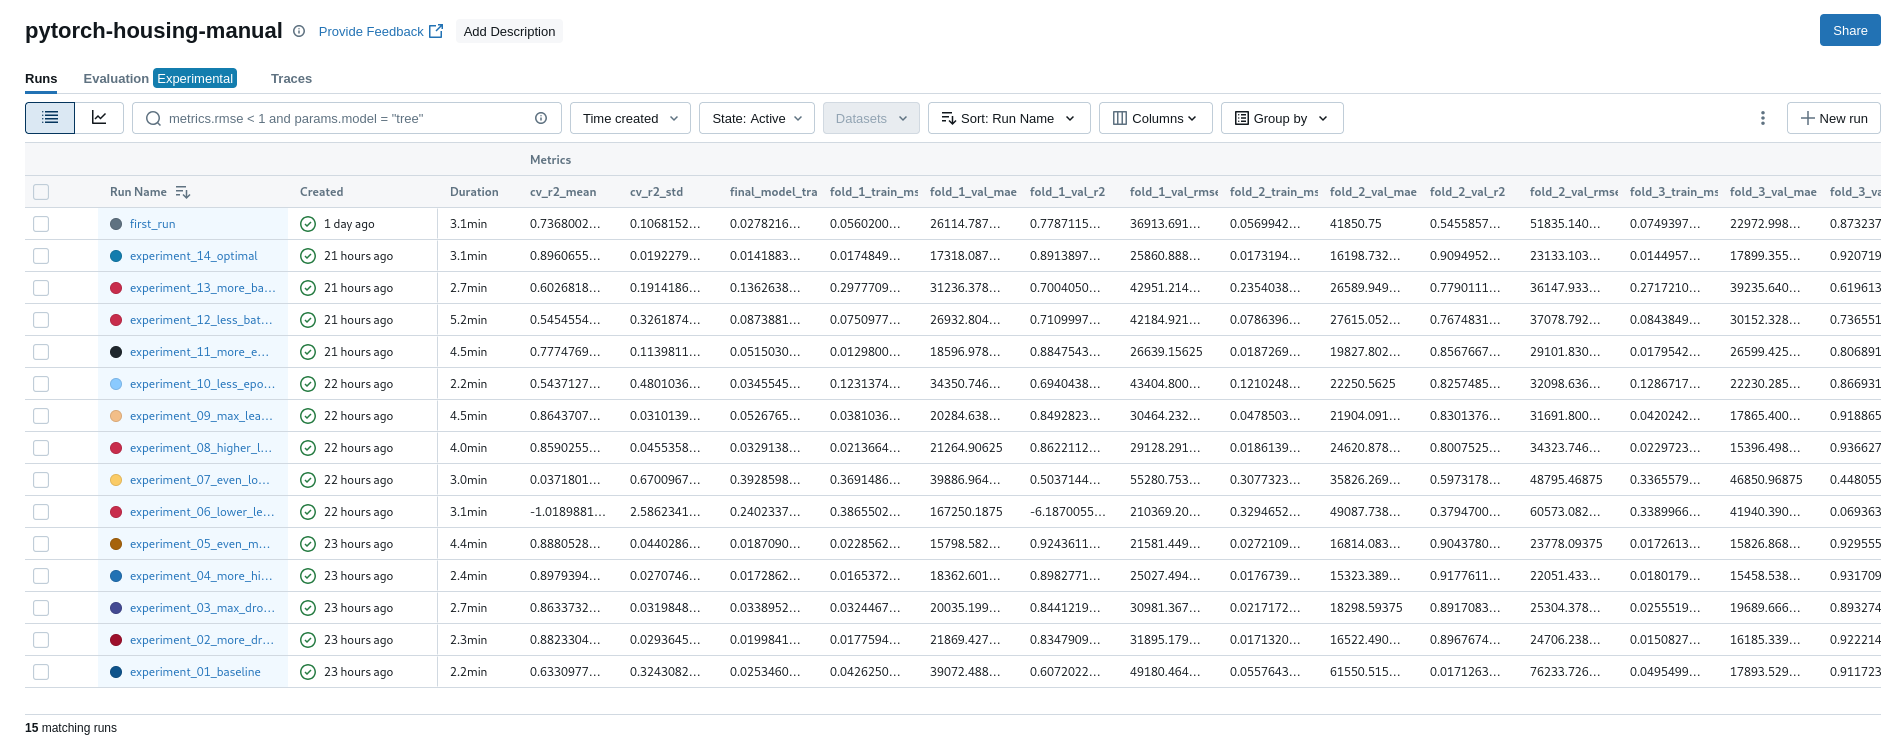

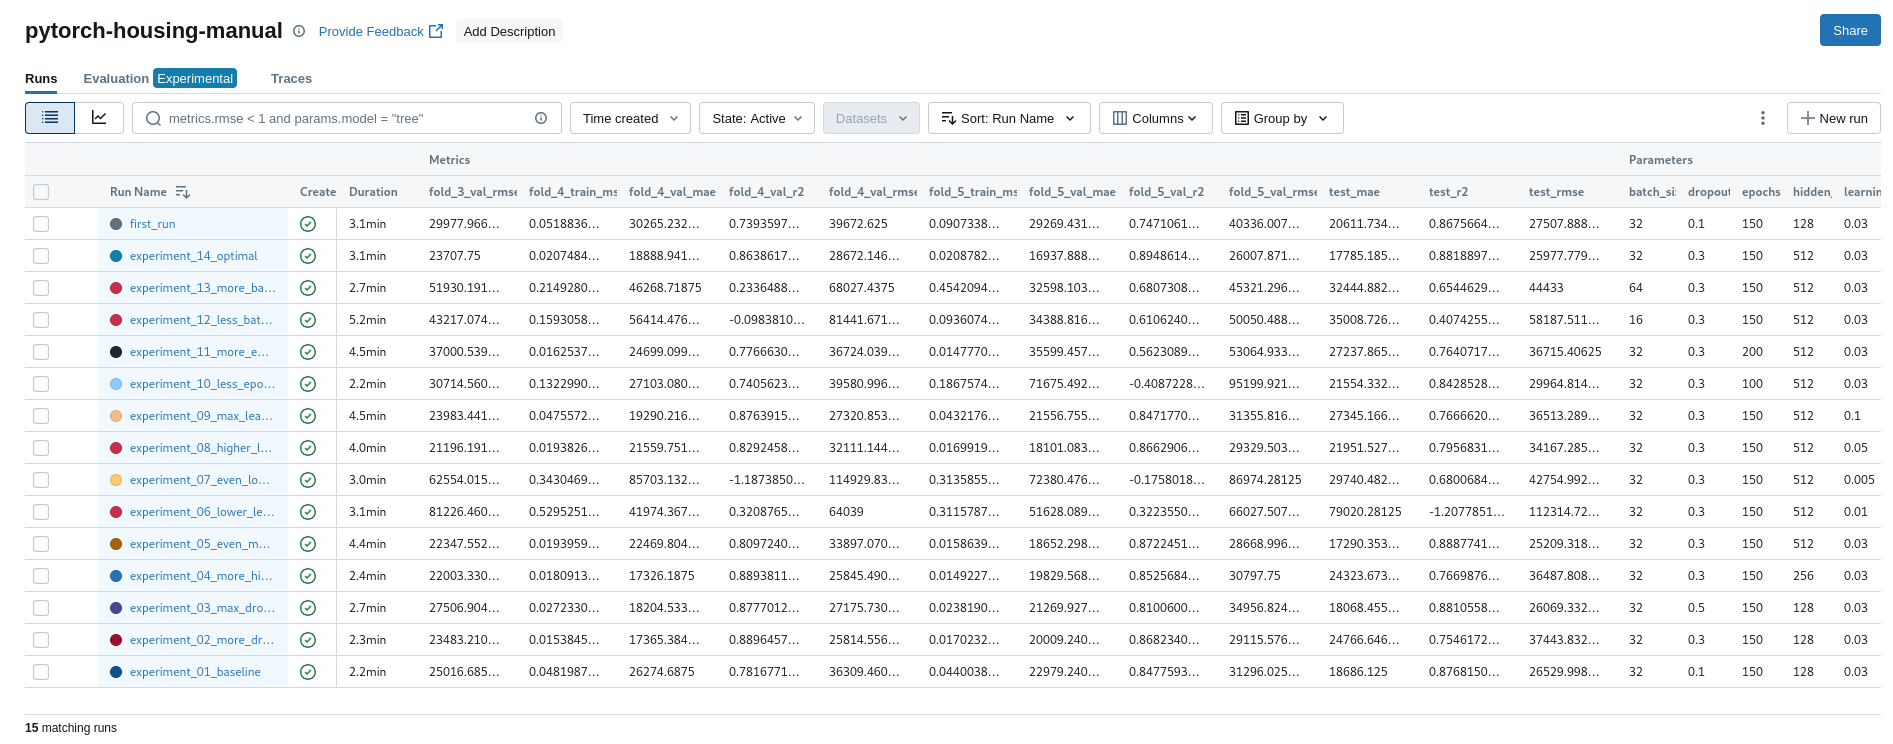

3. Comment on what changes impacted the model performance the most, and what changes disrupted the training process.

Performance:
Increasing hidden units had the strongest positive impact on performance. Improved the cv_r2 score from around 0.63 to nearly 0.89
Moderate regularization (dropout=0.3) improved generalization and reduced overfitting (high cv_r2_mean , low cv_std). Higher and lover values fot dropuot had worse results.
Learning rate tuning 0.03 provided the best results (high cv_r2_mean , low cv_std, test_r2 ≈ cv_r2_mean), Values for 0,05 - 0,1 were also in general quite good but worse than for 0.03.
Increasing epochs improved performance up to a point - for 200 epochs cv_std increased and cv_r2_mean and test_r2 descreased.

Training process:
Low learning_rate - prevented model from learning - low or negative cv_r2_mean
Too low and too high batch_size degraded performance.
Insufficient epochs - increased cv_std, decreased cv_r2_mean


4. Compare the results of our first scikit-learn configuration with the first PyTorch experiments. Do you see any overfitting in the first PyTorch experiment? Explain what signs of overfitting can indicate this situation.

Comparing first scikit-learn configuration with the first PyTorch experiments - scikit-learn models (Gradient Boosting as the best one) seem more stable (low std) with higher quality (high r2_mean), and generalize better (high r2_score_X_test)
There are signs of overfitting for first PyTorch experiment - high cv_std, big differences between folds in r2 metric (0,91- fold 3 and 0,01 - fold 2), average value of cv_r2_mean despite having good values in folds.